We need to create the yearly Carbon emission time varying txt for Winkelman 10,000 scenario,
Winkelman 10,000 carbon is released all in the first year
CO2 emission follows a logistic equition, see winkelman et al, 2015

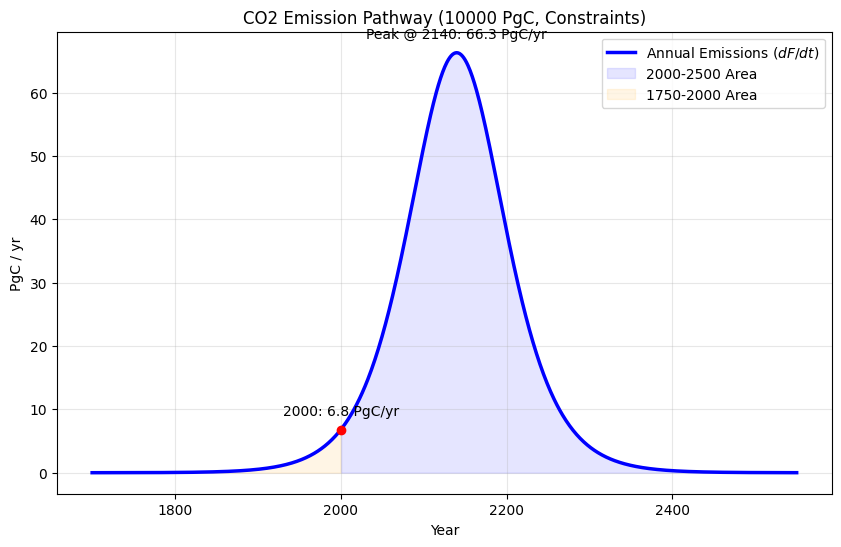

求解出的总资源量参数 A: 10271.37 PgC
1750-2000 实际积分: 270.00 PgC (目标: 270)
2000-2500 实际积分: 10000.00 PgC (目标: 10000)
2000年速率: 6.80 PgC/yr (目标: 6.8)
峰值年份: 2139.9, 峰值: 66.31 PgC/yr


In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson
from scipy.optimize import fsolve

# --- 1. 设定已知约束 ---
t0 = 1750
t1 = 2000
t2 = 2500

dFdt_2000_target = 6.8
integral_1750_2000_target = 270
integral_2000_2500_target = 10000  # 可改为5000或1000

def logistic_derivative(t, A, k, mu):
    exponent = -k * (t - mu)
    return (A * k * np.exp(exponent)) / (1 + np.exp(exponent))**2

# --- 2. 求解参数 A, k, mu ---
def solve_params(p):
    A, k, mu = p
    # 约束1: 2000年速率 = 6.8
    val_2000 = logistic_derivative(t1, A, k, mu) - dFdt_2000_target
    # 约束2: 1750-2000积分 = 270
    t_range1 = np.linspace(t0, t1, 500)
    y_range1 = logistic_derivative(t_range1, A, k, mu)
    integral1 = simpson(y_range1, t_range1) - integral_1750_2000_target
    # 约束3: 2000-2500积分 = 10000
    t_range2 = np.linspace(t1, t2, 1000)
    y_range2 = logistic_derivative(t_range2, A, k, mu)
    integral2 = simpson(y_range2, t_range2) - integral_2000_2500_target
    return [val_2000, integral1, integral2]

# 初值猜测
A0 = integral_1750_2000_target + integral_2000_2500_target
k0 = 0.02
mu0 = 2140
A_opt, k_opt, mu_opt = fsolve(solve_params, [A0, k0, mu0])

years = np.linspace(1700, 2550, 1000)
dfdt_pathway = logistic_derivative(years, A_opt, k_opt, mu_opt)

# 验证积分
t_range1 = np.linspace(t0, t1, 500)
y_range1 = logistic_derivative(t_range1, A_opt, k_opt, mu_opt)
integral_1750_2000 = simpson(y_range1, t_range1)
t_range2 = np.linspace(t1, t2, 1000)
y_range2 = logistic_derivative(t_range2, A_opt, k_opt, mu_opt)
integral_2000_2500 = simpson(y_range2, t_range2)
peak_val = np.max(dfdt_pathway)
peak_year = years[np.argmax(dfdt_pathway)]

plt.figure(figsize=(10, 6))
plt.plot(years, dfdt_pathway, 'b-', lw=2.5, label='Annual Emissions ($dF/dt$)')
plt.fill_between(years, dfdt_pathway, where=(years>=2000), color='blue', alpha=0.1, label='2000-2500 Area')
plt.fill_between(years, dfdt_pathway, where=(years>=1750) & (years<2000), color='orange', alpha=0.1, label='1750-2000 Area')
plt.scatter([2000], [dFdt_2000_target], color='red', zorder=5)
plt.annotate(f'2000: {dFdt_2000_target} PgC/yr', (2000, dFdt_2000_target), textcoords="offset points", xytext=(0,10), ha='center')
plt.annotate(f'Peak @ {peak_year:.0f}: {peak_val:.1f} PgC/yr', (peak_year, peak_val), textcoords="offset points", xytext=(0,10), ha='center')
plt.title('CO2 Emission Pathway (10000 PgC, Constraints)')
plt.xlabel('Year')
plt.ylabel('PgC / yr')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"求解出的总资源量参数 A: {A_opt:.2f} PgC")
print(f"1750-2000 实际积分: {integral_1750_2000:.2f} PgC (目标: {integral_1750_2000_target})")
print(f"2000-2500 实际积分: {integral_2000_2500:.2f} PgC (目标: {integral_2000_2500_target})")
print(f"2000年速率: {logistic_derivative(2000, A_opt, k_opt, mu_opt):.2f} PgC/yr (目标: {dFdt_2000_target})")
print(f"峰值年份: {peak_year:.1f}, 峰值: {peak_val:.2f} PgC/yr")

In [56]:
# 保存10000GtC情景的CO2排放为txt，格式与SSP585一致
save_years = np.arange(2000, 2501)
save_emissions = logistic_derivative(save_years, A_opt, k_opt, mu_opt)

save_path = "CO2_emissions_10000pgc.txt"
with open(save_path, 'w') as f:
    f.write("#%Year CO2_Emissions_Gtc_per_yr\n")
    for y, e in zip(save_years, save_emissions):
        f.write(f"{int(y)} {e:.6f}\n")
print(f"已保存到 {save_path}")

已保存到 CO2_emissions_1000GtC.txt
